In [7]:
import numpy as np

import pandas as pd
df = pd.read_csv('./chap_8/emails.csv')
df[:10]


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
5,"Subject: great nnews hello , welcome to medzo...",1
6,Subject: here ' s a hot play in motion homela...,1
7,Subject: save your money buy getting this thin...,1
8,Subject: undeliverable : home based business f...,1
9,Subject: save your money buy getting this thin...,1


In [8]:
X = df["text"]
y = df["spam"]

print(X.head())
print(y.head())

0    Subject: naturally irresistible your corporate...
1    Subject: the stock trading gunslinger  fanny i...
2    Subject: unbelievable new homes made easy  im ...
3    Subject: 4 color printing special  request add...
4    Subject: do not have money , get software cds ...
Name: text, dtype: str
0    1
1    1
2    1
3    1
4    1
Name: spam, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## chuyển đổi văn bản thành vector số bằng CountVectorizer
vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

model2 = LogisticRegression()
model2.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
y_pred2 = model2.predict(X_test_vec)

print(y_pred)
print(y_pred2)

[1 1 0 ... 0 1 0]
[1 1 0 ... 0 1 0]


In [15]:
## ĐÁnh giá
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

print("=" * 50)

print("Accuracy (Logistic Regression):", accuracy_score(y_test, y_pred2))
print("Precision (Logistic Regression):", precision_score(y_test, y_pred2))
print("Recall (Logistic Regression):", recall_score(y_test, y_pred2))
print("F1 (Logistic Regression):", f1_score(y_test, y_pred2))

print("Confusion Matrix (Logistic Regression):")
print(confusion_matrix(y_test, y_pred2))

print(classification_report(y_test, y_pred2))

print("=" * 50)

Accuracy: 0.9921465968586387
Precision: 0.9715302491103203
Recall: 0.9963503649635036
F1: 0.9837837837837838
Confusion Matrix:
[[864   8]
 [  1 273]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       872
           1       0.97      1.00      0.98       274

    accuracy                           0.99      1146
   macro avg       0.99      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146

Accuracy (Logistic Regression): 0.9912739965095986
Precision (Logistic Regression): 0.9680851063829787
Recall (Logistic Regression): 0.9963503649635036
F1 (Logistic Regression): 0.9820143884892086
Confusion Matrix (Logistic Regression):
[[863   9]
 [  1 273]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       872
           1       0.97      1.00      0.98       274

    accuracy                           0.99      1146
   macro avg       0.98      0.99      0.99  

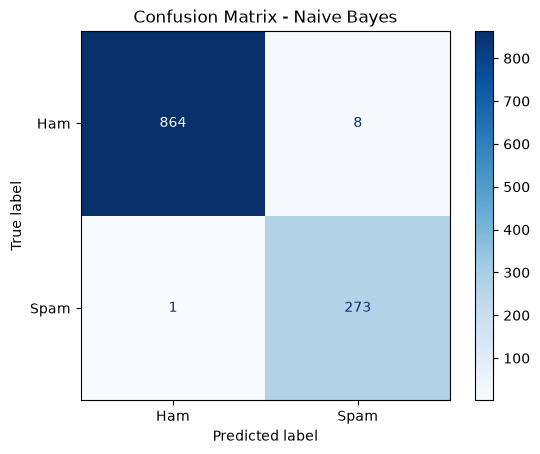

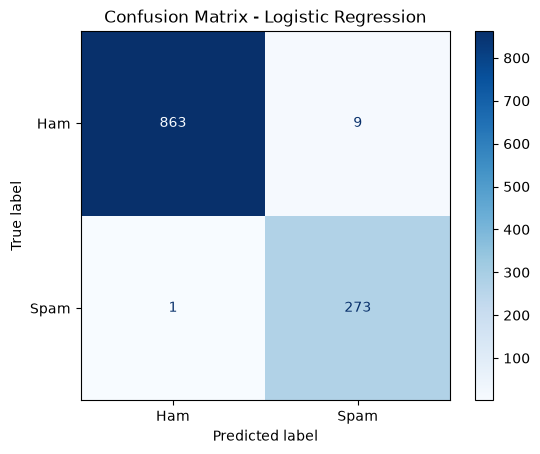

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Ham", "Spam"],
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Naive Bayes")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred2,
    display_labels=["Ham", "Spam"],
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [18]:
results = pd.DataFrame({
    "email": X_test.to_numpy(),
    "actual": y_test.to_numpy(),
    "predicted": y_pred
})

wrong = results[
    results["actual"] != results["predicted"]
]

print("Number of wrong predictions:", len(wrong))

for idx, row in wrong.head(5).iterrows():
    print(f"Email: {row['email']}")
    print(f"Actual: {row['actual']} | Predicted: {row['predicted']}")
    print("-" * 50)

Number of wrong predictions: 9
Email: Subject: us news archive @ ft . com  reliable country intelligence for a challenging world  with country reports supporting your decisions , you  ' re  working with the best source of country intelligence  available . turn to the economist intelligence unit at :  http : / / store . eiu . com  dear ft . com user  ft . com  ' s global archive can provide the answer to a multitude  of business queries :  * access information from more than 1 , 200 us business news  publications  * simultaneously search multiple sources e . g . business and  industry papers , business wire , and the pr newswire - usa .  * obtain a global view by searching across more than 6 million  articles worldwide .  with a variety of search options and powerful software , you will  be able to find the information you need in no time at all .  for the definitive answer to your business - related query , visit  and bookmark this page :  rch . jsp  regards ,  ft . com  why not forw